In [43]:
# ============================================================
# Standard library imports
# ============================================================
import os
import re
from pathlib import Path
from datetime import datetime

# ============================================================
# Third-party libraries – data handling
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Third-party libraries – visualization
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Global Configuration & Directories

This central configuration block manages all file paths and export behaviors for the project. By toggling `EXPORT_FILES`, you can safely run the scripts in memory for quick previews or write the final outputs (PDFs and CSVs) directly to your local and cloud directories.

**Key Variables:**
* `EXPORT_FILES`: Boolean toggle for safely saving or previewing data.
* `PLOT_OUTPUT_DIR`: Destination for all generated `.pdf` figures.
* `RESULTS_SHEET_PATH`: Destination for the dynamically generated blank sourdough data entry template.
* `input_file_metadata` & `CSV_OUTPUT_PATH`: Input and output paths for sequencing metadata processing.

In [48]:
# ============================================================
# --- Global Configuration & Directories ---
# ============================================================
# Set to True to physically save files to your drive
EXPORT_FILES = False

# 1. Master Output Directories (Plots & Results Sheet)
PLOT_OUTPUT_DIR = Path("Data_Analysis")
RESULTS_SHEET_PATH = Path("sourdough_results_sheet.csv")

# 2. Metadata Processing Paths
input_file_metadata = Path("20260225_sequence_list.csv")
CSV_OUTPUT_PATH = Path("metadata_output.csv")

# 3. Metabolomics Processing Paths (MZMINE & SIRIUS)
# MZMINE Quantification Table (Full feature table exported from MZMINE)
dir_mz_quant = Path("mzMine_SourDough_full_feature_table.csv")

# MZMINE Metadata Table (Sequence metadata)
# dir_mz_meta = Path("metadata_output.csv")

# SIRIUS Annotation Table (Structure identifications from SIRIUS)
dir_sirius = Path("structure_identifications.csv")

# ============================================================
# --- Directory Verification ---
# ============================================================
if EXPORT_FILES:
    PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_SHEET_PATH.parent.mkdir(parents=True, exist_ok=True)
    CSV_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("✅ Export mode is ON. Directories verified and ready.")
else:
    print("ℹ️ Export mode is OFF. Scripts will run in memory for preview only.")

ℹ️ Export mode is OFF. Scripts will run in memory for preview only.


## Data Visualization

This module generates publication-ready visualizations for the sourdough practicum data. It utilizes a custom helper function (`save_or_show`) to handle high-resolution PDF exports based on the global config.

**Visualizations Included:**
1.  **Time-Series Plot:** A dual-axis line/scatter plot tracking pH and Total Titratable Acidity (TTA) over time for Wheat and Spelt crops.
2.  **Paired Violin Plots:** Distribution comparisons of Bacterial and Yeast cell counts, covering both traditional plating (CFU/g) and Flow Cytometry (Live cells/g).

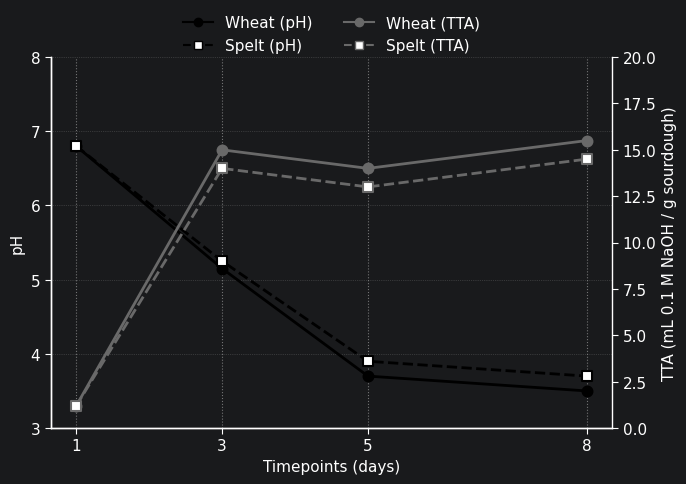

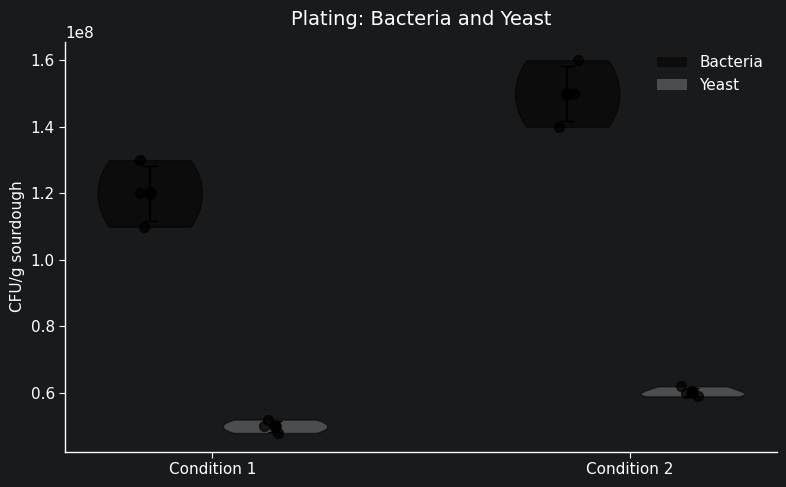

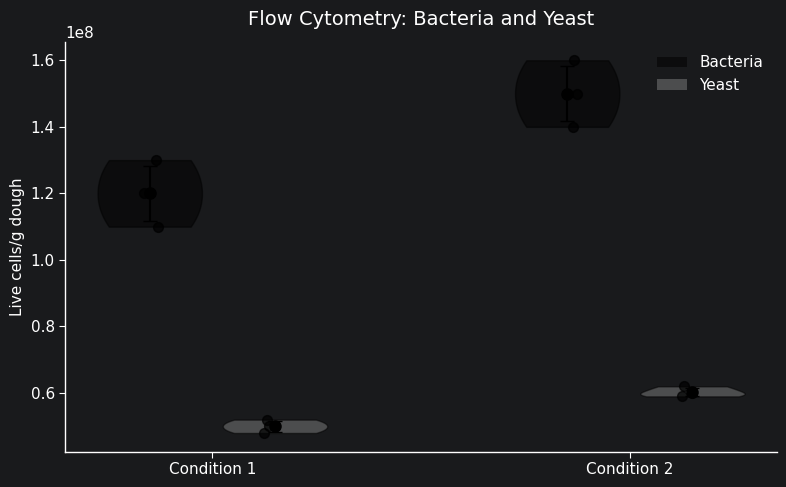

In [44]:
# ============================================================
# --- Global Plot Settings & Helper Functions ---
# ============================================================
plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11, "axes.linewidth": 1,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 4, "ytick.major.size": 4,
})

def save_or_show(filename, folder=PLOT_OUTPUT_DIR):
    """Helper function to handle exporting vs showing plots inline."""
    plt.tight_layout()
    if EXPORT_FILES:
        out_path = folder / filename
        plt.savefig(out_path, format='pdf', dpi=600, bbox_inches='tight')
        print(f"Saved: {out_path}")
    else:
        plt.show()
    plt.close()

# ============================================================
# --- 1. Time-Series Plot (pH & TTA) ---
# ============================================================
time_points = np.array([1, 3, 5, 8])

def generate_data(start_val, end_val, peak=None):
    """Generates synthetic curve data for preview."""
    if peak: return np.array([start_val, peak, peak - 1, peak + 0.5])
    return np.array([start_val, (start_val + end_val) / 2, end_val + 0.2, end_val])

data = {
    'Wheat': {'ph': generate_data(6.8, 3.5), 'tta': generate_data(1.2, None, peak=15)},
    'Spelt': {'ph': generate_data(6.8, 3.7), 'tta': generate_data(1.2, None, peak=14)}
}

fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

# Plot configurations: (axis, y_data, color, line_style, marker, is_filled)
plot_configs = [
    (ax1, data['Wheat']['ph'], "black", "-", "o", True),
    (ax1, data['Spelt']['ph'], "black", "--", "s", False),
    (ax2, data['Wheat']['tta'], "dimgray", "-", "o", True),
    (ax2, data['Spelt']['tta'], "dimgray", "--", "s", False)
]

for ax, y_data, color, ls, marker, fill in plot_configs:
    ax.plot(time_points, y_data, color=color, linestyle=ls, linewidth=2)
    facecolor = color if fill else 'white'
    ax.scatter(time_points, y_data, marker=marker, facecolors=facecolor,
               edgecolors=color, linewidth=1.5, s=50, zorder=3)

# Formatting
ax1.set(xlabel="Timepoints (days)", ylabel="pH", ylim=(3, 8), xticks=time_points)
ax2.set(ylabel="TTA (mL 0.1 M NaOH / g sourdough)", ylim=(0, 20))
ax1.grid(axis='x', linestyle=':', linewidth=0.8, alpha=0.6)
ax1.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.4)

for axis in [ax1, ax2]:
    axis.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Legend
handles = [
    Line2D([0], [0], color='black', ls='-', marker='o', label='Wheat (pH)'),
    Line2D([0], [0], color='black', ls='--', marker='s', markerfacecolor='white', label='Spelt (pH)'),
    Line2D([0], [0], color='dimgray', ls='-', marker='o', label='Wheat (TTA)'),
    Line2D([0], [0], color='dimgray', ls='--', marker='s', markerfacecolor='white', label='Spelt (TTA)')
]
ax1.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)

save_or_show("Sourdough_Final_Plot.pdf")

# ============================================================
# --- 2. Paired Violin Plots (Plating & Flow Cytometry) ---
# ============================================================
def plot_paired_violin(data_groups, conditions, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['black', 'gray']

    for i, (bact_data, yeast_data) in enumerate(data_groups):
        for j, (d, color, offset) in enumerate([(bact_data, colors[0], -0.15), (yeast_data, colors[1], 0.15)]):
            pos = i + offset

            # Violin bodies
            vp = ax.violinplot(d, positions=[pos], showmeans=False, showextrema=False, widths=0.25)
            for pc in vp['bodies']:
                pc.set_facecolor(color)
                pc.set_edgecolor('black')
                pc.set_alpha(0.5)

            # Scatter jitter & Error bars
            jitter = np.random.uniform(-0.03, 0.03, size=len(d))
            ax.scatter(pos + jitter, d, color='black', alpha=0.7, s=50)
            ax.errorbar(pos, np.mean(d), yerr=np.std(d), fmt='o', color='black', capsize=5, markersize=8)

    # Formatting
    ax.set(xticks=range(len(conditions)), xticklabels=conditions, ylabel=ylabel)
    ax.set_title(title, fontsize=14, pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    legend_handles = [Patch(facecolor='black', alpha=0.5, label='Bacteria'),
                      Patch(facecolor='gray', alpha=0.5, label='Yeast')]
    ax.legend(handles=legend_handles, frameon=False, loc='upper right')

    save_or_show(filename)

# Plot Execution
conditions = ['Condition 1', 'Condition 2']
mock_data = [
    (np.array([1.2e8, 1.3e8, 1.1e8]), np.array([5.0e7, 4.8e7, 5.2e7])),
    (np.array([1.5e8, 1.4e8, 1.6e8]), np.array([6.0e7, 6.2e7, 5.9e7]))
]

plot_paired_violin(mock_data, conditions, "CFU/g sourdough", "Plating: Bacteria and Yeast", "Plating_Bacteria_Yeast_Violin.pdf")
plot_paired_violin(mock_data, conditions, "Live cells/g dough", "Flow Cytometry: Bacteria and Yeast", "Flow_Bacteria_Yeast_Violin.pdf")

## Results Template Generator

To ensure uniform data collection across the lab, this script automatically constructs a standardized, formatted CSV template. It programmatically generates rows based on combinations of timepoints and lab groups, assigning unique Sample IDs formatted by the current date.

In [42]:
# ============================================================
# --- Define Columns ---
# ============================================================
columns = [
    "Sampling Day",
    "Group",
    "Condition",
    "Sample ID",
    "pH (unitless)",
    "TTA (mL 0.1M NaOH / 1 g dough)",
    "Yeast 10e-5 (CFU/g dough)",
    "Yeast 10e-6 (CFU/g dough)",
    "Yeast 10e-7 (CFU/g dough)",
    "LAB 10e-6 (CFU/g dough)",
    "LAB 10e-7 (CFU/g dough)",
    "LAB 10e-8 (CFU/g dough)",
    "CFU/g Yeast", "CFU/g LAB",
    "Flow cytometry Yeast (cells/g dough)",
    "Flow cytometry LAB (cells/g dough)",
    "Mean Yeast CFU/g",
    "SD Yeast CFU/g",
    "Mean LAB CFU/g",
    "SD LAB CFU/g"
]

# ============================================================
# --- Build Rows Dynamically ---
# ============================================================
today = datetime.today().strftime("%Y%m%d")

# List comprehension to efficiently generate all rows
rows = [
    [tp, g, "", f"{today}_{tp}_{g}"] + [""] * (len(columns) - 4)
    for tp in ["t1", "t3", "t5", "t8"]
    for g in range(1, 9)
]

df = pd.DataFrame(rows, columns=columns)

# ============================================================
# --- Export or Preview ---
# ============================================================
if EXPORT_FILES:
    df.to_csv(RESULTS_SHEET_PATH, index=False)
    print(f"✅ CSV template successfully created at:\n{RESULTS_SHEET_PATH}")
else:
    print(f"ℹ️ CSV built with {len(df)} rows. Export is OFF. Preview of first 5 rows:")
    display(df.head()) # Note: Use print(df.head()) if running outside of Jupyter

ℹ️ CSV built with 32 rows. Export is OFF. Preview of first 5 rows:


,Sampling Day,Group,Condition,Sample ID,pH (unitless),TTA (mL 0.1M NaOH / 1 g dough),Yeast 10e-5 (CFU/g dough),Yeast 10e-6 (CFU/g dough),Yeast 10e-7 (CFU/g dough),LAB 10e-6 (CFU/g dough),LAB 10e-7 (CFU/g dough),LAB 10e-8 (CFU/g dough),CFU/g Yeast,CFU/g LAB,Flow cytometry Yeast (cells/g dough),Flow cytometry LAB (cells/g dough),Mean Yeast CFU/g,SD Yeast CFU/g,Mean LAB CFU/g,SD LAB CFU/g
0,t1,1,,20260418_t1_1,,,,,,,,,,,,,,,,
1,t1,2,,20260418_t1_2,,,,,,,,,,,,,,,,
2,t1,3,,20260418_t1_3,,,,,,,,,,,,,,,,
3,t1,4,,20260418_t1_4,,,,,,,,,,,,,,,,
4,t1,5,,20260418_t1_5,,,,,,,,,,,,,,,,


## Sequence Metadata Extraction

This module automates the parsing of raw instrument sequence lists (e.g., mass spectrometer runs). By applying regular expressions and text matching to the raw filenames, it systematically extracts and structures critical experimental metadata into a clean CSV for downstream analysis.

**Key Extracted Variables:**
* **`file_name`**: Appends the standard `.mzML` extension.
* **`run_order`**: Extracts the precise 3-digit injection order from the filename.
* **`sample_type`**: Automatically classifies files into *Sample*, *Analytical Blank*, *Method Blank*, *Conditioning*, or *Pooled Sample* (QC).
* **`condition` & `timepoint`**: Identifies the specific crop (e.g., wheat, spelt) and the sampling day (t0–t8).
* **`group`**: Identifies the specific lab group (e.g., A, B, C) or defaults to '0' for starter cultures.

In [45]:
# ============================================================
# --- Read sequence list ---
# - skip first row (Bracket Type=4)
# - comma separated
# ============================================================
# UPDATED: using input_file_metadata instead of input_file
df = pd.read_csv(input_file_metadata, sep=",", skiprows=1)

# Keep and rename the relevant column
df = df[["File Name"]].copy()
df = df.rename(columns={"File Name": "raw_filename"})

# ============================================================
# --- 1. file_name (.mzML) ---
# ============================================================
df["file_name"] = df["raw_filename"].astype(str) + ".mzML"

# ============================================================
# --- 2. run_order (3-digit number between underscores) ---
# Example: _090_ → 90
# ============================================================
def extract_run_order(name):
    match = re.search(r'_(\d{3})_', name)
    return int(match.group(1)) if match else None

df["run_order"] = df["raw_filename"].apply(extract_run_order)

# ============================================================
# --- 3. sample_type classification ---
# ============================================================
def classify_sample_type(name):
    if "AnalyticalBlnk" in name:
        return "Analytical Blank"
    elif "MethodBlnk" in name:
        return "Method Blank"
    elif "QC_cond" in name:
        return "Conditioning"
    elif "QC" in name:
        return "Pooled Sample"
    else:
        return "Sample"

df["sample_type"] = df["raw_filename"].apply(classify_sample_type)

# ============================================================
# --- 4. condition (only for Samples) ---
# Rules: starter if _XXX_1_tX, otherwise detect crop
# ============================================================
def extract_condition(name, sample_type):
    if sample_type != "Sample":
        return None

    name_lower = name.lower()
    if re.search(r'_\d{3}_1_t\d+', name_lower):
        return "starter"

    for crop in ["buckwheat", "wheat", "dinkel", "spelt", "maize"]:
        if crop in name_lower:
            return crop
    return None

df["condition"] = df.apply(
    lambda row: extract_condition(row["raw_filename"], row["sample_type"]),
    axis=1
)

# ============================================================
# --- 5. timepoint (only for Samples) ---
# _t0 → 0, _t1 → 1, _t8 → 9
# ============================================================
def extract_timepoint(name, sample_type):
    if sample_type != "Sample":
        return None

    match = re.search(r'_t(\d+)', name)
    if match:
        tp = int(match.group(1))
        return 9 if tp == 8 else tp
    return None

df["timepoint"] = df.apply(
    lambda row: extract_timepoint(row["raw_filename"], row["sample_type"]),
    axis=1
)

# ============================================================
# --- 6. group (only for Samples) ---
# Starter → 0, otherwise last letter after final underscore
# ============================================================
def extract_group(name, sample_type):
    if sample_type != "Sample":
        return None

    if re.search(r'_\d{3}_1_t\d+', name):
        return 0

    match = re.search(r'_([A-Za-z])$', name)
    return match.group(1) if match else None

df["group"] = df.apply(
    lambda row: extract_group(row["raw_filename"], row["sample_type"]),
    axis=1
)

# ============================================================
# --- 7. condition_timepoint (only for Samples) ---
# Format: condition_timepoint (e.g., spelt_1)
# ============================================================
def merge_condition_timepoint(row):
    if row["sample_type"] != "Sample":
        return None
    if pd.notna(row["condition"]) and pd.notna(row["timepoint"]):
        return f"{row['condition']}_{row['timepoint']}"
    return None

df["condition_timepoint"] = df.apply(merge_condition_timepoint, axis=1)

# ============================================================
# --- 8. condition_timepoint_group (only for Samples) ---
# Format: condition_timepoint_group (e.g., spelt_1_D or starter_0_0)
# ============================================================
def merge_condition_timepoint_group(row):
    if row["sample_type"] != "Sample":
        return None
    if pd.notna(row["condition"]) and pd.notna(row["timepoint"]) and pd.notna(row["group"]):
        return f"{row['condition']}_{row['timepoint']}_{row['group']}"
    return None

df["condition_timepoint_group"] = df.apply(merge_condition_timepoint_group, axis=1)

# ============================================================
# --- Final metadata table (ordered columns) ---
# ============================================================
metadata = df[
    [
        "file_name",
        "run_order",
        "sample_type",
        "condition",
        "timepoint",
        "group",
        "condition_timepoint",
        "condition_timepoint_group",
    ]
]

# Respect global EXPORT_FILES toggle
if EXPORT_FILES:
    # UPDATED: using CSV_OUTPUT_PATH instead of output_file
    metadata.to_csv(CSV_OUTPUT_PATH, index=False)
    print("Metadata file successfully written to:\n", CSV_OUTPUT_PATH)
else:
    print("Export is OFF. Preview of generated metadata:")
    display(metadata.head())

Export is OFF. Preview of generated metadata:


,file_name,run_order,sample_type,condition,timepoint,group,condition_timepoint,condition_timepoint_group
0,260226_Hpos_000_AnalyticalBlnk.mzML,0,Analytical Blank,NaN,NaN,None,NaN,NaN
1,260226_Hneg_000_AnalyticalBlnk.mzML,0,Analytical Blank,NaN,NaN,None,NaN,NaN
2,260226_Hpos_001_AnalyticalBlnk.mzML,1,Analytical Blank,NaN,NaN,None,NaN,NaN
3,260226_Hneg_001_AnalyticalBlnk.mzML,1,Analytical Blank,NaN,NaN,None,NaN,NaN
4,260226_Hpos_002_AnalyticalBlnk.mzML,2,Analytical Blank,NaN,NaN,None,NaN,NaN


## Metabolomics Data Import (MZmine & SIRIUS)

This section handles the ingestion of processed metabolomics data into pandas DataFrames for downstream statistical analysis and visualization. It loads the quantitative feature tables generated by MZmine alongside the structural annotations predicted by SIRIUS.

**Key DataFrames:**
* **`QUANT`**: The MZmine quantification table containing all detected metabolic features, including their *m/z* values, retention times, and peak areas across all samples.
* **`SIRIUS`**: The annotation table containing putative structural identifications and chemical classifications for the detected features.
* **`META`**: *(Currently disabled)* The sequence metadata table (generated in the previous steps) used to map sample names to their respective biological conditions.

In [50]:
# ============================================================
# --- Load MZMINE Quantification Table ---
# ============================================================
QUANT = pd.read_csv(dir_mz_quant, sep=None, engine="python")

# ============================================================
# --- Load MZMINE Metadata Table (optional) ---
# Currently commented out
# ============================================================
# META = pd.read_csv(dir_mz_meta, sep=None, engine="python")

# ============================================================
# --- Load SIRIUS Annotation Table ---
# ============================================================
SIRIUS = pd.read_csv(dir_sirius)

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/lauracam/01_Projects/2026/20260226_SourDough/mzMine_SourDough_full_feature_table.csv'

## Data Integration & Feature Mapping

This module bridges the gap between raw quantification (MZmine) and chemical annotation (SIRIUS). It extracts the relevant peak area columns, cleans up the verbose instrument file names, and generates a highly descriptive, human-readable index for every detected metabolic feature.

**Key Operations:**
* **Type Alignment:** Enforces integer data types on `id` and `mappingFeatureId` to ensure perfect matching between the two tables.
* **Sample Column Cleaning:** Strips the redundant `mzML:area` prefix from column names, leaving only the clean, exact sample names.
* **Dynamic Feature Indexing:** Iterates through the dataset to build a composite row name for every feature:
  * *Annotated features:* Format `[ID] | [Name or SMILES] | [Adduct]`
  * *Unannotated features:* Format `[ID] | [m/z] | [Retention Time]` (designed specifically for compatibility with Volcano Plot filters).
* **Final Matrix (`Feature_df`):** Yields a clean matrix containing only the peak areas and InChIKeys, indexed by the new descriptive names, completely ready for downstream statistical analysis.

In [52]:
# ============================================================
# --- Ensure consistent data types for merging ---
# ============================================================
SIRIUS['mappingFeatureId'] = SIRIUS['mappingFeatureId'].astype(int)
QUANT['id'] = QUANT['id'].astype(int)

# ============================================================
# --- Identify sample columns and trim names ---
# Keep only columns containing "mzML:area" and extract meaningful sample names
# ============================================================
sample_cols = {col: col.split(':')[1] for col in QUANT.columns if "mzML:area" in col}

# ============================================================
# --- Create Feature DataFrame ---
# Copy only the sample columns and rename them
# ============================================================
Feature_df = QUANT[list(sample_cols.keys())].copy()
Feature_df.rename(columns=sample_cols, inplace=True)

# ============================================================
# --- Map features to SIRIUS annotations ---
# Build index names and InChIKey list
# ============================================================
names = []
inchi = []

for feature_id in QUANT['id']:
    # Retrieve annotation from SIRIUS
    rows_sirius = SIRIUS.loc[
        SIRIUS['mappingFeatureId'] == feature_id,
        ['name', 'smiles', 'adduct', 'InChIkey2D']
    ]

    # Retrieve mz and rt from QUANT
    rows_mzmine = QUANT.loc[
        QUANT['id'] == feature_id,
        ['mz', 'rt']
    ]

    mz = rows_mzmine.iloc[0]['mz']
    rt = rows_mzmine.iloc[0]['rt']
    add = str(feature_id)  # start index string with feature ID

    if rows_sirius.empty:
        # Feature not annotated: append mz and rt for VolcanoPlotter "Only Annotated" filter
        add = f"{add} | {mz:.4f}mz | {rt:.2f}min"
        inchi.append("")
    else:
        # Feature annotated in SIRIUS
        name_val = rows_sirius.iloc[0]['name']
        smiles = rows_sirius.iloc[0]['smiles']
        adduct = rows_sirius.iloc[0]['adduct']
        inchikey = rows_sirius.iloc[0]['InChIkey2D']
        inchi.append(inchikey)

        # Prefer name; fallback to SMILES if name is missing
        if pd.isna(name_val) or str(name_val).strip() == "":
            add = f"{add} | {smiles} | {adduct}"
        else:
            add = f"{add} | {name_val} | {adduct}"

    names.append(add)

# ============================================================
# --- Final Feature DataFrame setup ---
# Set descriptive index and append InChIKey column
# ============================================================
Feature_df.index = names
Feature_df['InchiKey'] = inchi

NameError: name 'SIRIUS' is not defined

## Data Export (Feature Table)

This final step saves the fully processed and integrated feature matrix to a CSV file. The resulting table contains the custom descriptive indices, quantitative peak areas across all samples, and structural identifiers (InChIKeys). This clean dataset is now fully prepped for downstream statistical analysis (e.g., PCA, Volcano plots, Heatmaps).

In [53]:
# ============================================================
# --- Export Feature Table ---
# Save the processed feature table including descriptive index and InChIKey
# ============================================================
Feature_df.to_csv(
    r"/Volumes/lauracam/01_Projects/2026/20260226_SourDough/Statistics/featureTable_SourDough.csv",
    index=True
)

# ============================================================
# --- Export Metadata Table (optional) ---
# Currently commented out; uncomment if META is available
# ============================================================
# META.to_csv(
#     r"/Volumes/lauracam/01_Projects/2026/20260226_SourDough/Statistics/metaData_SourDough.csv",
#     index=False
# )

NameError: name 'Feature_df' is not defined